In [ ]:
!unzip Images_7.zip

Archive:  Images_7.zip
   creating: Images_7/
   creating: Images_7/New_7_classes/
   creating: Images_7/New_7_classes/angry/
  inflating: Images_7/New_7_classes/angry/0_0.jpg  
  inflating: Images_7/New_7_classes/angry/0_25.jpg  
  inflating: Images_7/New_7_classes/angry/0_29.jpg  
  inflating: Images_7/New_7_classes/angry/100_22.jpg  
  inflating: Images_7/New_7_classes/angry/100_24.jpg  
  inflating: Images_7/New_7_classes/angry/100_29.jpg  
  inflating: Images_7/New_7_classes/angry/101_19.jpg  
  inflating: Images_7/New_7_classes/angry/101_3.jpg  
  inflating: Images_7/New_7_classes/angry/101_32.jpg  
  inflating: Images_7/New_7_classes/angry/102_17.jpg  
  inflating: Images_7/New_7_classes/angry/102_20.jpg  
  inflating: Images_7/New_7_classes/angry/102_34.jpg  
  inflating: Images_7/New_7_classes/angry/103_16.jpg  
  inflating: Images_7/New_7_classes/angry/103_23.jpg  
  inflating: Images_7/New_7_classes/angry/103_32.jpg  
  inflating: Images_7/New_7_classes/angry/104_11.jpg  
  

In [ ]:
DATASET_DIR = "Images_7/New_7_classes"

In [ ]:
import os

class_counts = {}

for cls in os.listdir(DATASET_DIR):
    cls_path = os.path.join(DATASET_DIR, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

print("Class-wise Distribution:\n")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")


Class-wise Distribution:

neutral: 420
sad: 419
surprise: 419
angry: 420
disgust: 420
happy: 420
fear: 420


In [ ]:
import os
import shutil
import random

SOURCE_DIR = "/content/Images_7/New_7_classes"
TARGET_DIR = "/content/Images_7_split"

TRAIN_RATIO = 0.8                  # 80% train, 20% validation


for split in ["train", "validation"]:
    for cls in os.listdir(SOURCE_DIR):
        os.makedirs(os.path.join(TARGET_DIR, split, cls), exist_ok=True)


random.seed(42)  # for reproducibility

for cls in os.listdir(SOURCE_DIR):
    cls_path = os.path.join(SOURCE_DIR, cls)
    images = [
        img for img in os.listdir(cls_path)
        if img.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    random.shuffle(images)

    split_index = int(len(images) * TRAIN_RATIO)
    train_images = images[:split_index]
    val_images = images[split_index:]

    # Copy train images
    for img in train_images:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(TARGET_DIR, "train", cls, img)
        )

    # Copy validation images
    for img in val_images:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(TARGET_DIR, "validation", cls, img)
        )

    print(f"{cls}: Train={len(train_images)}, Validation={len(val_images)}")



neutral: Train=336, Validation=84
sad: Train=335, Validation=84
surprise: Train=335, Validation=84
angry: Train=336, Validation=84
disgust: Train=336, Validation=84
happy: Train=336, Validation=84
fear: Train=336, Validation=84


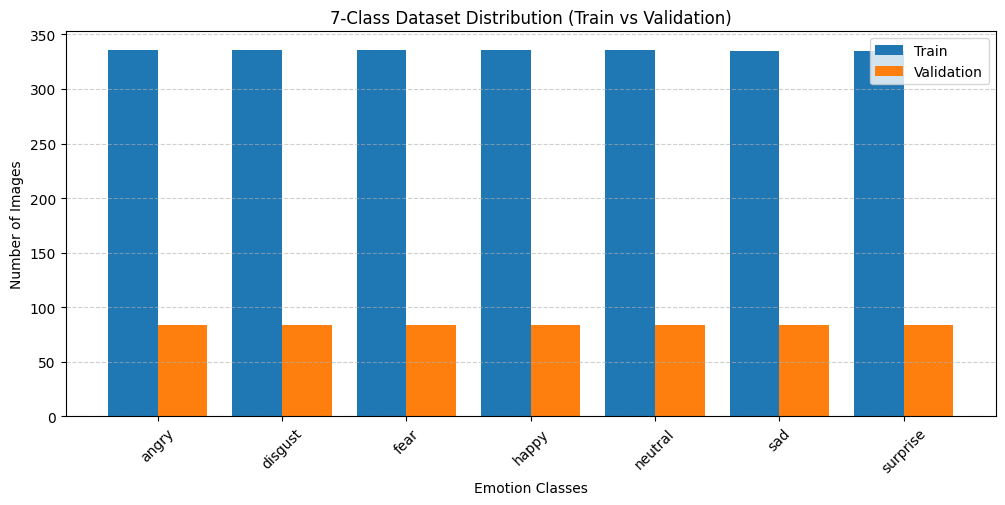

In [ ]:
import os
import matplotlib.pyplot as plt

# Paths
DATASET_DIR = "/content/Images_7_split"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "validation")

# Get class names automatically (7 classes)
CLASSES = sorted(os.listdir(TRAIN_DIR))

# Count images
train_counts = {
    cls: len([
        f for f in os.listdir(os.path.join(TRAIN_DIR, cls))
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    for cls in CLASSES
}

val_counts = {
    cls: len([
        f for f in os.listdir(os.path.join(VAL_DIR, cls))
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    for cls in CLASSES
}

# Plot
plt.figure(figsize=(12,5))
x = range(len(CLASSES))

plt.bar(
    [i - 0.2 for i in x],
    train_counts.values(),
    width=0.4,
    label='Train'
)
plt.bar(
    [i + 0.2 for i in x],
    val_counts.values(),
    width=0.4,
    label='Validation'
)

plt.xticks(x, CLASSES, rotation=45)
plt.xlabel("Emotion Classes")
plt.ylabel("Number of Images")
plt.title("7-Class Dataset Distribution (Train vs Validation)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt


In [ ]:
IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 100

TRAIN_DIR = "/content/Images_7_split/train"
VAL_DIR   = "/content/Images_7_split/validation"


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt


train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    shuffle=False
)

NUM_CLASSES = len(train_ds.class_names)
print("Classes:", train_ds.class_names)



Found 2350 files belonging to 7 classes.
Found 588 files belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
])


In [ ]:
normalization_layer = layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(normalization_layer(x)), y)
).prefetch(AUTOTUNE)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
).prefetch(AUTOTUNE)


In [ ]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation='softmax')
])


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),  # 🔥 higher LR
    loss='sparse_categorical_crossentropy',                  # ❌ no label smoothing
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,855 (4.36 MB)

 Trainable params: 1,142,855 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    # callbacks=callbacks
)


Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 17s 142ms/step - accuracy: 0.1290 - loss: 1.9560 - val_accuracy: 0.2415 - val_loss: 1.9386
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.1872 - loss: 1.9352 - val_accuracy: 0.2075 - val_loss: 1.8960
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.2115 - loss: 1.8993 - val_accuracy: 0.2721 - val_loss: 1.8214
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.2680 - loss: 1.8333 - val_accuracy: 0.3265 - val_loss: 1.6710
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.3560 - loss: 1.6873 - val_accuracy: 0.5170 - val_loss: 1.3665
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.4319 - loss: 1.5164 - val_accuracy: 0.5629 - val_loss: 1.1721
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.4751 - loss: 1.3612 - val_accuracy: 0.6139 - val_loss: 1.0814
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.4876 - loss: 1.3010 - val_accuracy

In [ ]:
train_acc = history.history['accuracy'][-1]
val_acc   = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy     : {train_acc:.4f}")
print(f"Final Validation Accuracy   : {val_acc:.4f}")


Final Training Accuracy     : 0.8868
Final Validation Accuracy   : 0.8333


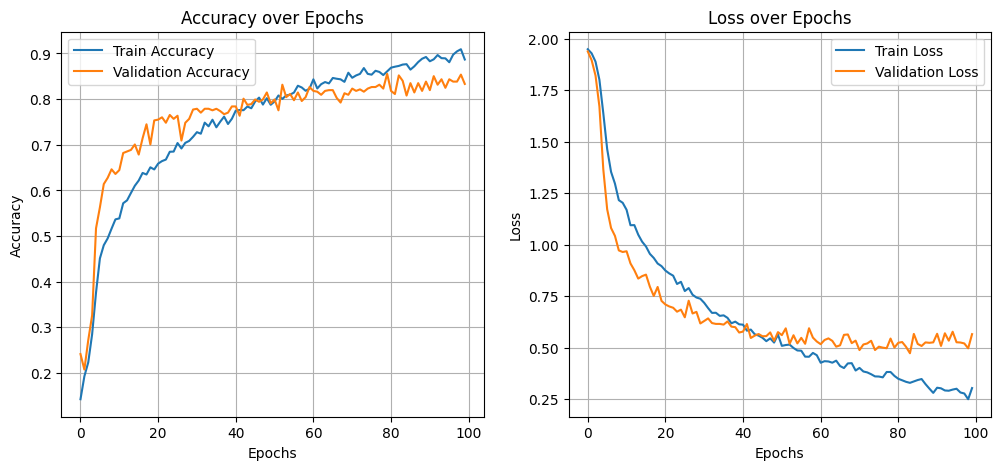

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()
plt.grid(True)

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


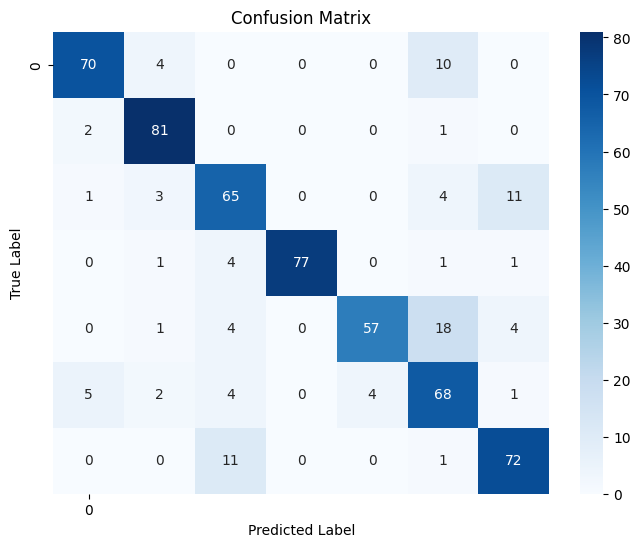

In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=NUM_CLASSES,
    yticklabels=NUM_CLASSES
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

